# Fraud Detection Notebook

In [6]:
from pathlib import Path

import json
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config.configuration import AppConfig
from src.pipelines.portfolio_showcase_pipeline import run_portfolio_showcase_pipeline

sns.set_theme(style='whitegrid')
assets_dir = project_root / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)

config = AppConfig.from_env()
df = pd.read_csv(project_root / 'data' / 'raw' / 'transactions.csv')
df.head()

,transaction_id,user_id,transaction_amount,transaction_time,location,device,merchant_category,payment_channel,is_international,card_present,previous_transactions_24h,avg_spend_7d,label
0,tx_00001,1394,1880.70,2024-02-16 10:10:00,CA,mobile,fashion,wallet,0,1,5,501.09,0
1,tx_00002,253,906.65,2024-02-05 19:09:00,WA,tablet,gaming,wallet,0,1,5,168.30,0
2,tx_00003,1091,133.61,2024-01-04 14:18:00,WA,mobile,electronics,wallet,0,1,9,1811.47,0
3,tx_00004,524,2264.52,2024-02-26 06:06:00,WA,mobile,fashion,wallet,0,1,1,145.85,0
4,tx_00005,122,412.21,2024-02-26 13:13:00,TX,mobile,fashion,card,1,1,5,206.99,0


In [7]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
display(df.describe(include='all').T.head(20))

class_table = (
    df['label']
    .value_counts()
    .rename_axis('label')
    .to_frame('count')
    .assign(ratio=lambda x: (x['count'] / x['count'].sum()).round(4))
)
display(class_table)

Rows: 320
Columns: 13


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,320,320,tx_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,320.0,NaN,NaN,NaN,961.93125,487.78641,101.0,533.75,963.5,1385.25,1796.0
transaction_amount,320.0,NaN,NaN,NaN,1969.240125,2348.054209,20.81,664.0625,1493.375,2244.485,13836.39
transaction_time,320,319,2024-03-20 10:28:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,320,6,NY,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,320,3,desktop,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,320,6,gaming,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_channel,320,3,wallet,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_international,320.0,NaN,NaN,NaN,0.1625,0.369487,0.0,0.0,0.0,0.0,1.0
card_present,320.0,NaN,NaN,NaN,0.63125,0.483222,0.0,0.0,1.0,1.0,1.0


,count,ratio
label,,
0,288,0.9
1,32,0.1


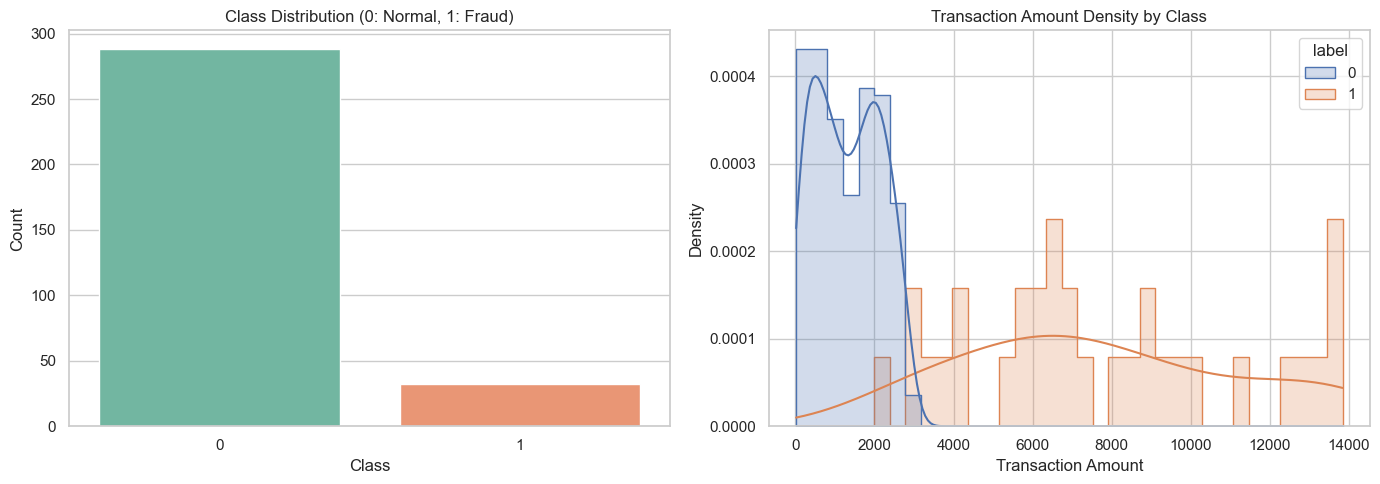

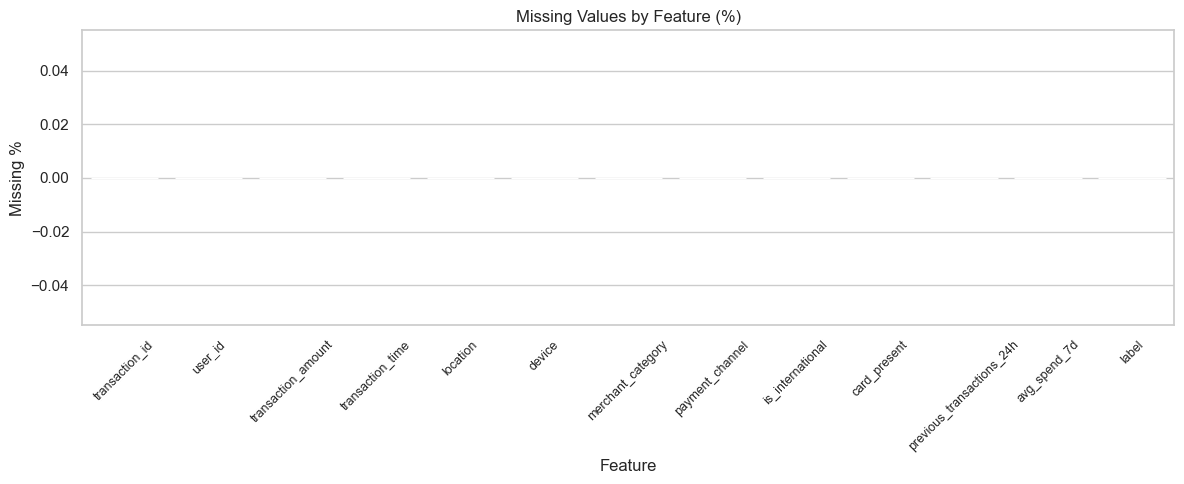

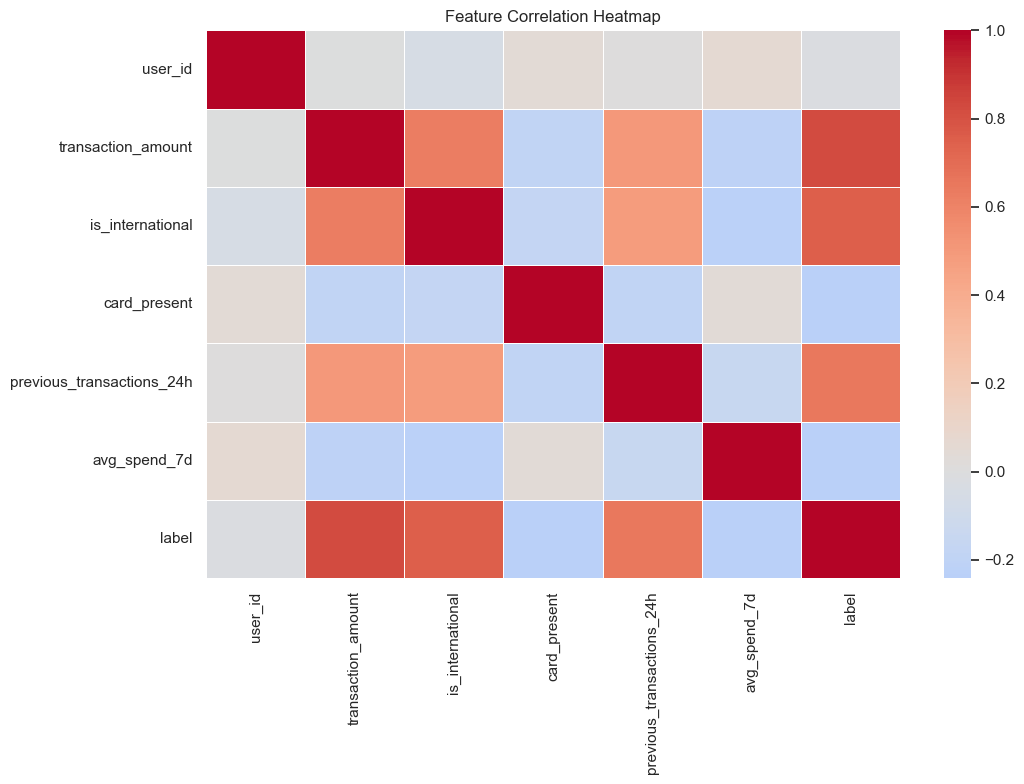

In [8]:
# EDA Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts = df['label'].value_counts().sort_index()
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, hue=class_counts.index.astype(str), legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution (0: Normal, 1: Fraud)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

sns.histplot(data=df, x='transaction_amount', hue='label', bins=35, kde=True, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Transaction Amount Density by Class')
axes[1].set_xlabel('Transaction Amount')
fig.tight_layout()
fig.savefig(assets_dir / 'eda_distribution.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

# Missing Values
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, ax=ax, color='#4C78A8')
ax.set_title('Missing Values by Feature (%)')
ax.set_xlabel('Feature')
ax.set_ylabel('Missing %')
ax.tick_params(axis='x', rotation=45, labelsize=9)
fig.tight_layout()
fig.savefig(assets_dir / 'missing_values.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

# Correlation Heatmap
numeric_cols = df.select_dtypes(include=['number', 'bool']).columns.tolist()
corr = df[numeric_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.4, ax=ax)
ax.set_title('Feature Correlation Heatmap')
fig.tight_layout()
fig.savefig(assets_dir / 'correlation_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

In [9]:
# Generate full showcase assets (model visuals + API visual + real predictions)
manifest = run_portfolio_showcase_pipeline(config)
manifest

2026-04-16 21:59:58 | INFO | src.pipelines.prediction_pipeline | event=application | Prediction generated fraud=False probability=0.0002
2026-04-16 21:59:58 | INFO | src.pipelines.prediction_pipeline | event=application | Prediction generated fraud=False probability=0.0000
2026-04-16 21:59:58 | INFO | src.pipelines.prediction_pipeline | event=application | Prediction generated fraud=True probability=1.0000


{'eda_distribution': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\fraud_detection_system\\assets\\eda_distribution.png',
 'missing_values': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\fraud_detection_system\\assets\\missing_values.png',
 'correlation_heatmap': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\fraud_detection_system\\assets\\correlation_heatmap.png',
 'model_comparison': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\fraud_detection_system\\assets\\model_comparison.png',
 'confusion_matrix': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\fraud_detection_system\\assets\\confusion_matrix.png',
 'roc_curve': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\fraud_detection_system\\assets\\roc_curve.png',
 'feature_importance': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\fraud_detection_system\\assets\\feature_importance.png',
 'api_response': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\fraud_detection_system\\assets\\api

In [10]:
metrics_path = project_root / 'artifacts' / 'metrics.json'
samples_path = project_root / 'artifacts' / 'output_samples.json'

with metrics_path.open('r', encoding='utf-8') as f:
    metrics = json.load(f)
with samples_path.open('r', encoding='utf-8') as f:
    samples = json.load(f)

display(pd.Series(metrics, name='value').to_frame())
samples

,value
threshold,0.987661
precision,1.000000
recall,1.000000
f1_score,1.000000
roc_auc,1.000000
true_negative,58.000000
false_positive,0.000000
false_negative,0.000000
true_positive,6.000000
false_negative_rate,0.000000


{'samples': [{'input': {'transaction_id': 'tx_00168',
    'user_id': 1662,
    'transaction_amount': 1906.11,
    'transaction_time': '2024-01-06 15:45:00',
    'location': 'IL',
    'device': 'tablet',
    'merchant_category': 'grocery',
    'payment_channel': 'card',
    'is_international': 0,
    'card_present': 1,
    'previous_transactions_24h': 7,
    'avg_spend_7d': 627.35},
   'actual_label': 0,
   'output': {'prediction': 'Normal',
    'probability': 0.0002,
    'threshold': 0.9877,
    'model_version': '1.0'}},
  {'input': {'transaction_id': 'tx_00231',
    'user_id': 1448,
    'transaction_amount': 260.78,
    'transaction_time': '2024-03-11 11:33:00',
    'location': 'IL',
    'device': 'desktop',
    'merchant_category': 'utilities',
    'payment_channel': 'wallet',
    'is_international': 0,
    'card_present': 1,
    'previous_transactions_24h': 3,
    'avg_spend_7d': 295.45},
   'actual_label': 0,
   'output': {'prediction': 'Normal',
    'probability': 0.0,
    'thresh

## Key Insights

- Fraud signals are dominated by extreme amount-to-spend ratio, velocity, and international/channel context.
- Threshold tuning is optimized for high precision while preserving strong recall.
- Portfolio assets and prediction examples are fully auto-generated for recruiter-ready demonstration.